# Installing & Importing Libraries

In [1]:
%pip install transformers datasets timm evaluate torch icecream -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [2]:
from icecream import ic # type: ignore

# Download Dataset

In [3]:
from pathlib import Path
ic(Path.cwd())

ic| Path.cwd(): PosixPath('/content')


PosixPath('/content')

In [10]:
%pwd

'/content'

In [ ]:
# import shutil
from pathlib import Path
import kagglehub # pyright: ignore[reportMissingImports]
cache_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset",
    path="plantvillage dataset/color",
    # output_dir="/content",
    # force_download=True
    )
print("Path to dataset files:", cache_path)

# # Move to your the current directory
# destination=Path("plantvillage_dataset")
# destination.mkdir(exist_ok=True, parents=True)
# shutil.copytree(cache_path, destination, dirs_exist_ok=True)

# print("Dataset moved to", destination)


In [22]:
!ls "$cache_path"

 Apple___Apple_scab
 Apple___Black_rot
 Apple___Cedar_apple_rust
 Apple___healthy
 Blueberry___healthy
'Cherry_(including_sour)___healthy'
'Cherry_(including_sour)___Powdery_mildew'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___healthy'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
'Grape___Esca_(Black_Measles)'
 Grape___healthy
'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
'Orange___Haunglongbing_(Citrus_greening)'
 Peach___Bacterial_spot
 Peach___healthy
 Pepper,_bell___Bacterial_spot
 Pepper,_bell___healthy
 Potato___Early_blight
 Potato___healthy
 Potato___Late_blight
 Raspberry___healthy
 Soybean___healthy
 Squash___Powdery_mildew
 Strawberry___healthy
 Strawberry___Leaf_scorch
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___healthy
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___Target_Spot
 Tomato___Tomato_mosaic_virus
 Tomato_

In [24]:
# Display data 
print("Directories containing images")
%ls "$cache_path"|head
print("Images in the Directories")
%ls "$cache_path"/Apple___Apple_scab/|head

Directories containing images
Apple___Apple_scab/
Apple___Black_rot/
Apple___Cedar_apple_rust/
Apple___healthy/
Blueberry___healthy/
Cherry_(including_sour)___healthy/
Cherry_(including_sour)___Powdery_mildew/
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/
Corn_(maize)___Common_rust_/
Corn_(maize)___healthy/
Images in the Directories
00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
03354abb-aa1c-4f9d-a1ef-9f40505cd539___FREC_Scab 3355.JPG
0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
0395b847-2c73-4674-826f-33a6afb5b4fe___FREC_Scab 3287.JPG


# Load Dataset

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    cache_path,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [26]:
ic(train_loader)
ic(val_loader)

ic| train_loader: <torch.utils.data.dataloader.DataLoader object at 0x7ae036b531a0>
ic| val_loader: <torch.utils.data.dataloader.DataLoader object at 0x7ae037350770>


# Load Pretrained Vision Transformer

In [27]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=len(dataset.classes),
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([38])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


# Device Setup

In [28]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

# Define Loss + Optimizer

In [29]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5
)

# Training Loop

In [32]:
from tqdm import tqdm

epochs = 3

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)

        loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

100%|██████████| 1358/1358 [27:47<00:00,  1.23s/it]


Epoch 1, Loss: 61.08366894116625


100%|██████████| 1358/1358 [27:40<00:00,  1.22s/it]


Epoch 2, Loss: 22.20702701836126


100%|██████████| 1358/1358 [27:40<00:00,  1.22s/it]

Epoch 3, Loss: 20.011340963625116


# Validation Accuracy

In [33]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)

        _, predicted = torch.max(outputs.logits, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 99.23579780867324


# Save Model

In [34]:
torch.save(model.state_dict(), "plant_vit.pth")

# Demo Prediction

Tomato___Bacterial_spot


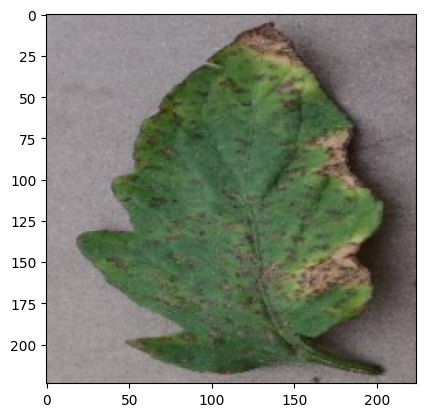

In [37]:
import matplotlib.pyplot as plt

images, labels = next(iter(val_loader))

image = images[0].permute(1,2,0)

plt.imshow(image)

model.eval()

with torch.no_grad():

    outputs = model(
        pixel_values=images[0].unsqueeze(0).to(device)
    )

pred = outputs.logits.argmax(-1)

print(dataset.classes[pred])